# Tutorial 3 · Training a neural network to retrieve rain from link signals

**What this notebook covers.** How to train a data-driven retrieval: why one might
replace the power law, how to build inputs and targets from link signals and a
reference, how to split the data so that the test is honest, and how to compare the
trained model with the physics baseline. The model is small and trains in about a
minute on a CPU, on the 8-day OpenMRG example subset.

**Prerequisites.** [Tutorial 2](02_cml_signal_to_rain.ipynb) (the physical chain).
PyTorch is installed with the `opensense` extra.

**Contents**
1. Why learn the retrieval?
2. Inputs: one hour of excess loss per link
3. Target: the radar along the path
4. Splitting by time
5. A small recurrent network
6. Training
7. Test: network against power law
8. What this toy leaves out
9. References and links

## 1. Why learn the retrieval?

The chain of Tutorial 2 has several hand-set parts: a wet/dry rule, a baseline rule, a
wet-antenna model whose parameters do not transfer between networks, and a power law
that assumes a uniform drop-size distribution along the path. Each choice moves the
result, and Tutorial 2 showed the wet-antenna step alone changing an event total by a
factor of three. A network trained against a reference can learn these corrections
jointly from the signal itself.

Habi & Messer (2021) proposed a two-step recurrent network - a wet/dry classifier and
a rain-rate regressor sharing a recurrent backbone - released in the
[PyNNcml](https://github.com/haihabi/PyNNcml) library. FieldSense's
`projects/cml_rnn` trains it on three networks, and finds that it beats every
power-law method on held-out weeks in Gothenburg, Emilia-Romagna and New York. This
notebook builds a simpler model of the same family from scratch, so that each step is
visible.

In [1]:
import contextlib
import io
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr

from core.cml import rnn
from core.opensense import example_data
from core.opensense import intercomparison_chain as ic

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)

with contextlib.redirect_stdout(io.StringIO()):
    data = example_data.load("openmrg", "8d")
cml_10s, radar = data["cml"], data["radar"]
print(f"{cml_10s.sizes['cml_id']} links x {cml_10s.sizes['sublink_id']} sublinks, "
      f"{pd.Timestamp(cml_10s.time.values[0]):%d %b} - {pd.Timestamp(cml_10s.time.values[-1]):%d %b %Y}")

364 links x 2 sublinks, 22 Jul - 29 Jul 2015


## 2. Inputs: one hour of excess loss per link

The unit of data is one **sublink-hour**. For each, `core.cml.rnn.features` (the input
of FieldSense's RNN) computes:

* the 60 one-minute values of *excess loss*: total loss minus a causal baseline (the
  median of the previous 24 hours of 15-minute medians - it uses only the past, so it
  can run in real time);
* four hourly summaries: share of missing minutes, mean and maximum excess, standard
  deviation of the loss.

`rnn.metadata` adds what the network needs to know about the link itself: frequency,
length, polarization and the ITU-R P.838-3 coefficients. And `rnn.physics_features`
applies the power law to the excess loss - the physics as an input, so the network
only has to learn a correction to it.

These functions take a *link set*: one row per sublink (`link` dimension) with
frequency in GHz, length in km and polarization `v`/`h`. We build one from the
OpenSense-format file, at 1-minute resolution.

In [2]:
cml = cml_10s[["tsl", "rsl"]].resample(time="1min").mean()
links = cml.stack(link=("cml_id", "sublink_id")).transpose("link", "time")
link_index = links.indexes["link"]
pol_raw = cml_10s.polarization.transpose("cml_id", "sublink_id").values.astype(str)
pol = np.where(np.char.startswith(np.char.lower(pol_raw), "v"), "v", "h")
links = links.drop_vars(["link", "cml_id", "sublink_id"]).assign_coords(
    link=np.arange(links.sizes["link"]),
    cml_id=("link", link_index.get_level_values("cml_id")),
    sublink_id=("link", link_index.get_level_values("sublink_id")),
    frequency=("link", cml_10s.frequency_ghz.transpose("cml_id", "sublink_id").values.ravel()),
    length=("link", np.repeat(cml_10s.length_km.values, cml_10s.sizes["sublink_id"])),
    polarization=("link", pol.ravel()),
)
links

<xarray.Dataset> Size: 134MB
Dimensions:        (link: 728, time: 11520)
Coordinates: (12/19)
    site_0_lat     (link) float64 6kB 57.7 57.7 57.73 ... 57.66 57.71 57.71
    site_0_lon     (link) float64 6kB 12.0 12.0 11.98 ... 12.03 12.01 12.01
    site_1_lat     (link) float64 6kB 57.7 57.7 57.72 ... 57.63 57.71 57.71
    site_1_lon     (link) float64 6kB 11.99 11.99 11.97 ... 11.97 11.98 11.98
    frequency      (link) float64 6kB 28.21 29.21 38.53 ... 29.19 28.25 29.26
    polarization   (link) <U1 3kB 'v' 'v' 'v' 'v' 'v' ... 'v' 'v' 'v' 'v' 'v'
    ...             ...
    x              (link) float64 6kB 6.784e+05 6.784e+05 ... 6.785e+05
    y              (link) float64 6kB 6.399e+06 6.399e+06 ... 6.4e+06 6.4e+06
  * time           (time) datetime64[ns] 92kB 2015-07-22 ... 2015-07-29T23:59:00
  * link           (link) int64 6kB 0 1 2 3 4 5 6 ... 722 723 724 725 726 727
    cml_id         (link) int64 6kB 10001 10001 10002 ... 10363 10364 10364
    sublink_id     (link) object 6kB 'sublink_1' 'sublink_2' ... 'sublink_2'
Data variables:
    tsl            (link, time) float64 67MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    rsl            (link, time) float64 67MB -46.0 -46.0 -46.0 ... -49.2 -49.2
Attributes: (12/14)
    title:                 OpenMRG-CML
    version:               1.1
    source:                Swedish Meteorological and Hydrological Institute ...
    contact:               hydro.fou@smhi.se, jafet.andersson@smhi.se
    license:               https://creativecommons.org/licenses/by-sa/4.0
    doi:                   https://doi.org/10.5281/zenodo.6673750
    ...                    ...
    institution:           NA
    date:                  NA
    history:               NA
    naming convention:     NA
    license restrictions:  NA
    reference:             NA

In [3]:
hours = pd.date_range("2015-07-23 01:00", "2015-07-30 00:00", freq="1h")   # hour-ending; day 1 is history
t0 = time.time()
X = rnn.features(links, hours)                     # (link, hour, 64)
M = rnn.metadata(links)                            # (link, 5)
P = rnn.physics_features(X, M)                     # (link, hour, 3): power-law mean, max, of-mean (mm/h)
print(f"features {X.shape}, metadata {M.shape}, physics {P.shape} in {time.time() - t0:.0f} s")

features (728, 168, 64), metadata (728, 5), physics (728, 168, 3) in 1 s


## 3. Target: the radar along the path

A supervised model needs a reference at the same place and time. Here it is the radar
averaged along each path (poligrain intersect weights, Tutorial 4), as an hour-ending
total in mm. `projects/cml_rnn` uses the mean of radar and nearby gauges instead,
because a model trained on radar alone learns the radar's errors along with the rain.

In [4]:
along = ic.radar_along_links(radar.R, cml_10s, radar.lon.values, radar.lat.values)   # mm/h, 5 min
target_hourly = along.resample(time="1h", label="right", closed="right").mean()       # mm per hour
Y = target_hourly.sel(cml_id=links.cml_id.values, time=hours).transpose("cml_id", "time").values  # (link, hour)
print("target", Y.shape, f"- {np.mean(Y > 0.1):.1%} of sublink-hours above 0.1 mm")

target (728, 168) - 22.8% of sublink-hours above 0.1 mm


## 4. Splitting by time

Rain is correlated in time and in space: neighbouring hours look alike, and so do
neighbouring links at the same hour. A random split of sublink-hours would put the
same storm in training and test, and the test score would measure memory, not skill.
The split is therefore by **day**, and the normalization statistics are computed on
the training set only:

| set | hours (hour-ending) | role |
|---|---|---|
| train | 23 Jul 01:00 - 28 Jul 00:00 | fit the weights |
| validation | 28 Jul | choose the epoch (early stopping) |
| test | 29 Jul | report, once |

The same links appear in all three sets, so this tests generalization to new storms,
not to new links or networks - `projects/cml_rnn` holds out whole weeks on three
networks.

Most sublink-hours are dry. In the training set only, 70% of the clearly dry ones (no
rain on the radar, no excess loss above 1 dB) are dropped, which shortens training and
keeps the model from settling on "always dry". Validation and test keep every hour.

In [5]:
split = np.where(hours <= "2015-07-28 00:00", "train", np.where(hours <= "2015-07-29 00:00", "val", "test"))
seq = X[:, :, :rnn.N_MIN].reshape(X.shape[0], X.shape[1], 12, 5).mean(-1)   # (link, hour, 12) 5-min mean excess
static = np.concatenate([X[:, :, rnn.N_MIN:],                 # 4 summaries
                         np.broadcast_to(M[:, None, :], X.shape[:2] + (M.shape[1],)),
                         P], axis=-1)                         # (link, hour, 12)
ok = np.isfinite(Y) & (X[:, :, rnn.N_MIN] < 0.5) & np.isfinite(static).all(-1)

sets = {}
rng = np.random.default_rng(0)
dry = (Y <= 0.1) & (X[:, :, rnn.N_MIN + 2] < 1.0)              # no rain and no excess above 1 dB
for name in ["train", "val", "test"]:
    m = ok & (split == name)[None, :]
    if name == "train":                                       # keep 30% of the clearly dry training hours
        m &= ~dry | (rng.random(m.shape) < 0.3)
    sets[name] = (seq[m], static[m], Y[m], P[..., 0][m])
    print(f"{name:5s} {m.sum():6d} sublink-hours, {np.mean(Y[m] > 0.1):5.1%} wet, mean {Y[m].mean():.3f} mm")

mu_s, sd_s = sets["train"][1].mean(0), sets["train"][1].std(0) + 1e-6
SEQ_SCALE = 10.0                                              # excess loss in dB, about 0-60


def tensors(name):
    s, st, y, _ = sets[name]
    return (torch.tensor(s / SEQ_SCALE, dtype=torch.float32)[..., None],
            torch.tensor((st - mu_s) / sd_s, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32))


train, val, test = tensors("train"), tensors("val"), tensors("test")

train  42055 sublink-hours, 39.5% wet, mean 0.376 mm
val    16961 sublink-hours, 28.9% wet, mean 0.289 mm
test   16264 sublink-hours, 34.1% wet, mean 0.602 mm


## 5. A small recurrent network

A gated recurrent unit ([GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html))
reads the hour of excess loss as 12 five-minute means (averaging the 60 minutes cuts
the training time five-fold at little cost for hourly totals); its final state is joined with the hourly
summaries, the link metadata and the power-law rates, and a small fully connected head
predicts the hour's rain. A softplus output keeps it non-negative. The model is
deliberately small, because the training examples come from a handful of storms.

In [6]:
class HourlyGRU(torch.nn.Module):
    def __init__(self, n_static: int, hidden: int = 32):
        super().__init__()
        self.gru = torch.nn.GRU(1, hidden, batch_first=True)
        self.head = torch.nn.Sequential(
            torch.nn.Linear(hidden + n_static, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 1), torch.nn.Softplus())

    def forward(self, seq, static):
        _, h = self.gru(seq)                                  # h: (1, batch, hidden)
        return self.head(torch.cat([h[0], static], dim=-1)).squeeze(-1)


model = HourlyGRU(n_static=train[1].shape[1])
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

6,305 parameters


## 6. Training

Mean squared error on hourly totals, the Adam optimizer, mini-batches of 512, 20
epochs, and the weights of the epoch with the lowest validation loss kept. The
training loss is the mean over each epoch's batches (so it lags the weights slightly).

trained in 40 s; best validation MSE 0.331 at epoch 3


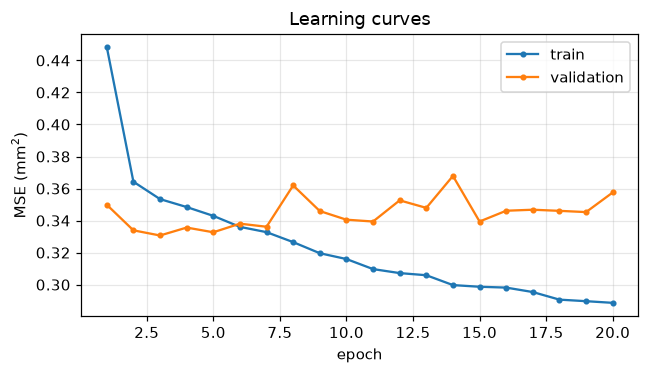

In [7]:
def evaluate(m, d):
    m.eval()
    with torch.no_grad():
        return torch.nn.functional.mse_loss(m(d[0], d[1]), d[2]).item()


opt = torch.optim.Adam(model.parameters(), lr=2e-3)
history, best = [], (np.inf, None)
n = len(train[2])
t0 = time.time()
for epoch in range(20):
    model.train()
    perm, batch_losses = torch.randperm(n), []
    for i in range(0, n, 512):
        b = perm[i:i + 512]
        loss = torch.nn.functional.mse_loss(model(train[0][b], train[1][b]), train[2][b])
        opt.zero_grad()
        loss.backward()
        opt.step()
        batch_losses.append(loss.item() * len(b))
    history.append({"epoch": epoch + 1, "train": sum(batch_losses) / n, "validation": evaluate(model, val)})
    if history[-1]["validation"] < best[0]:
        best = (history[-1]["validation"], {k: v.clone() for k, v in model.state_dict().items()})
model.load_state_dict(best[1])
hist = pd.DataFrame(history).set_index("epoch")
print(f"trained in {time.time() - t0:.0f} s; best validation MSE {best[0]:.3f} at epoch {hist.validation.idxmin()}")

ax = hist.plot(figsize=(6, 3.5), marker=".")
ax.set(ylabel="MSE (mm$^2$)", title="Learning curves")
plt.tight_layout()

## 7. Test: network against power law

The baseline is the power law applied to the same excess loss (`physics_features`, the
hourly mean of the per-minute rates), with no wet-antenna correction and the same
causal baseline. Scores on the test day, with poligrain's standard metrics (wet
threshold 0.1 mm for the detection scores).

In [8]:
import poligrain as plg

model.eval()
with torch.no_grad():
    pred = model(test[0], test[1]).numpy()
y_test, pl_test = sets["test"][2], sets["test"][3]

rows = {}
for name, est in [("power law", pl_test), ("GRU", pred)]:
    m = plg.validation.calculate_rainfall_metrics(reference=y_test, estimate=est, ref_thresh=0.1, est_thresh=0.1)
    rows[name] = {"RMSE (mm/h)": m["root_mean_square_error"], "MAE (mm/h)": m["mean_absolute_error"],
                  "correlation": m["pearson_correlation_coefficient"], "bias (%)": m["percent_bias"],
                  "rain in false alarms (mm/h)": m["false_positive_mean_rainfall"]}
scores = pd.DataFrame(rows).T
scores.round(3)

,RMSE (mm/h),MAE (mm/h),correlation,bias (%),rain in false alarms (mm/h)
power law,5.562,2.535,0.447,166.168,1.181
GRU,1.604,0.912,0.652,-48.227,0.268


The power law without a wet-antenna correction reads far too much rain, mostly in
hours the radar calls light or dry. The network removes most of that excess and
correlates better with the radar, but it underestimates the heavy hours: a model
trained with a squared-error loss on a few storms regresses towards the mean, and the
learning curves show it starts to overfit after a few epochs.

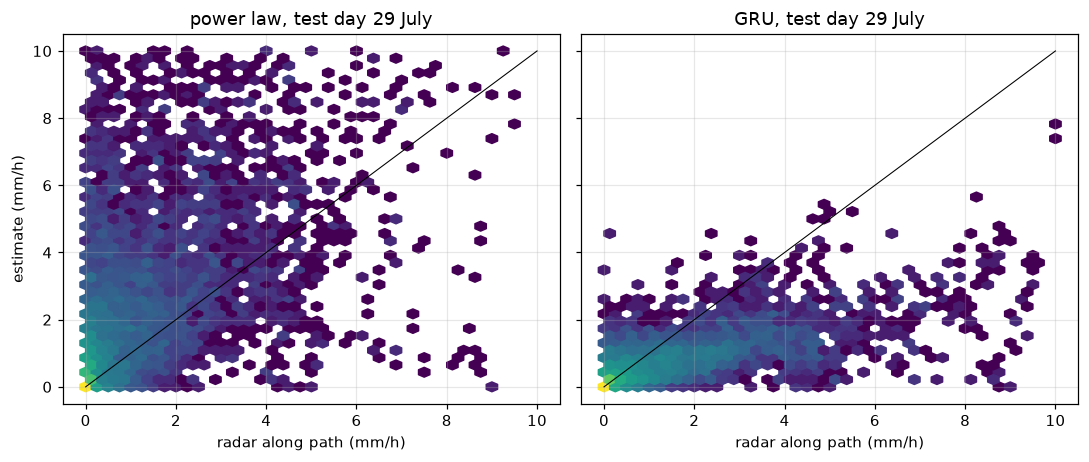

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), sharex=True, sharey=True)
for ax, (name, est) in zip(axes, [("power law", pl_test), ("GRU", pred)]):
    ax.hexbin(y_test, est, gridsize=40, bins="log", extent=(0, 10, 0, 10), mincnt=1, cmap="viridis")
    ax.plot([0, 10], [0, 10], "k-", lw=0.7)
    ax.set(xlabel="radar along path (mm/h)", title=f"{name}, test day 29 July")
axes[0].set_ylabel("estimate (mm/h)")
plt.tight_layout()

A time series for the sublinks with the most rain on the test day:

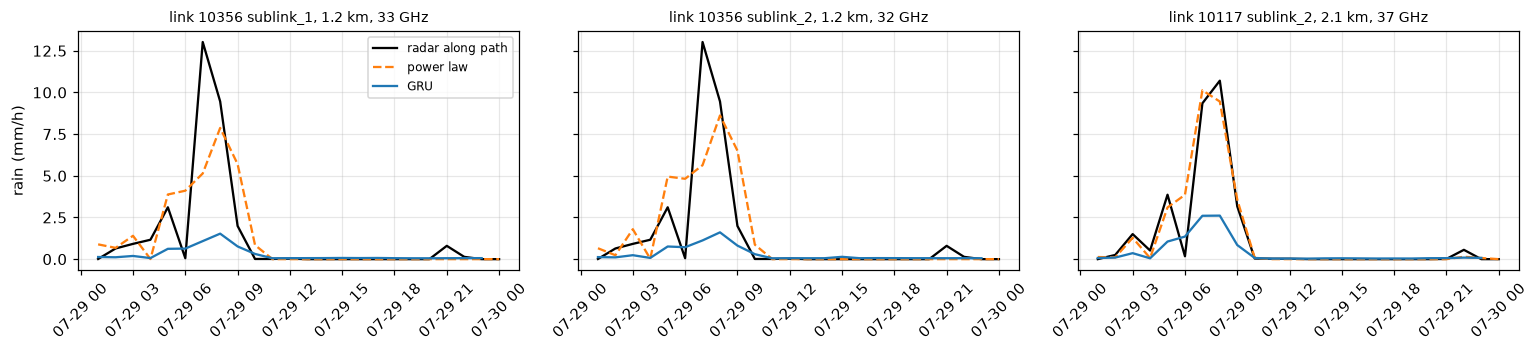

In [10]:
test_mask = ok & (split == "test")[None, :]
pred_full = np.full(Y.shape, np.nan)
pred_full[test_mask] = pred
test_hours = hours[split == "test"]
top = np.argsort(-np.nansum(np.where(test_mask, Y, 0), axis=1))[:3]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3), sharey=True)
for ax, k in zip(axes, top):
    sel = split == "test"
    ax.plot(test_hours, Y[k, sel], "k-", label="radar along path")
    ax.plot(test_hours, P[k, sel, 0], "C1--", label="power law")
    ax.plot(test_hours, pred_full[k, sel], "C0-", label="GRU")
    ax.set_title(f"link {links.cml_id.values[k]} {links.sublink_id.values[k]}, "
                 f"{links.length.values[k]:.1f} km, {links.frequency.values[k]:.0f} GHz", fontsize=9)
    ax.tick_params(axis="x", labelrotation=45)
axes[0].set_ylabel("rain (mm/h)")
axes[0].legend(fontsize=8)
plt.tight_layout()

The comparison is between a model that has seen this network's links against this
radar for five days and a power law that has seen nothing; on a single test day of
one network, the numbers above show what the approach can do, not how well it
generalizes. They are not a result.

## 8. What this toy leaves out

* **More data, more networks.** Five training days contain a few storms. The model in
  `projects/cml_rnn` is trained on three networks over months and tested on held-out
  weeks; `core.cml.rnn.HourlyRNN` loads it for use on any link set.
* **A better target.** Training against radar teaches the radar's biases. The project
  uses the mean of radar and gauges and evaluates against each separately.
* **Neighbours.** `rnn.neighbour_features` adds what the surrounding links see (the
  nearby-link idea of Overeem et al., 2016), which helps most where links are dense.
* **Wet/dry as a task.** PyNNcml's two-step network learns wet/dry classification and
  rain rate jointly (Habi & Messer, 2018, 2021); a classification head helps with the
  many dry hours.
* **Held-out links.** Testing on links the model never saw, or a network it never saw,
  is the real test of transfer.

**Next:** [Tutorial 4](04_weather_radar.ipynb) looks at the reference used here - the
weather radar - and at its errors.

## 9. References and links

* Habi, H. V., and Messer, H. (2018). Wet-dry classification using LSTM and commercial microwave links. *IEEE SAM Workshop*, 149-153. [doi:10.1109/SAM.2018.8448679](https://doi.org/10.1109/SAM.2018.8448679)
* Habi, H. V., and Messer, H. (2021). Recurrent neural network for rain estimation using commercial microwave links. *IEEE Trans. Geosci. Remote Sens.*, 59, 3672-3681. [doi:10.1109/TGRS.2020.3010305](https://doi.org/10.1109/TGRS.2020.3010305)
* Overeem, A., Leijnse, H., and Uijlenhoet, R. (2016). Retrieval algorithm for rainfall mapping from microwave links in a cellular communication network. *Atmos. Meas. Tech.*, 9, 2425-2444. [doi:10.5194/amt-9-2425-2016](https://doi.org/10.5194/amt-9-2425-2016)
* Polz, J., Chwala, C., Graf, M., and Kunstmann, H. (2020). Rain event detection in commercial microwave link attenuation data using convolutional neural networks. *Atmos. Meas. Tech.*, 13, 3835-3853. [doi:10.5194/amt-13-3835-2020](https://doi.org/10.5194/amt-13-3835-2020)
* Software: [PyNNcml](https://github.com/haihabi/PyNNcml), [PyTorch GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html), [poligrain](https://poligrain.readthedocs.io)
* In this repository: `projects/cml_rnn` (training on three networks), `core/cml/rnn.py` (features and the trained model), `projects/cml_retrieval/notebooks/rnn_retrieval.ipynb`